In [1]:
# 1. Imports and Paths
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set these to your repo structure
ARTIFACTS = Path("../miniature-fishstick/artifacts/baselines/lgbm_numeric_v1_subsample")
OUTPUT = Path("../miniature-fishstick/output")

In [2]:
# 2. Load EO JSONL (Evidence Objects)
eo_path = ARTIFACTS / "eos_test_with_drivers.jsonl"
with open(eo_path) as f:
    eo = [json.loads(line) for line in f]
eo_df = pd.DataFrame(eo)
print("Number of EO records:", len(eo_df))
eo_df.head(2)

Number of EO records: 20000


,schema_version,domain,created_utc,git_sha,model,split_id,event_id,score,risk_band,recommended_action_class,top_drivers,thin_file_flag,evidence_strength,data_coverage_score,monitoring,meta
0,eo_v0,fraud,2026-03-06T09:40:14.105194Z,3e8331fefd5df8f19bcc0fbc7ea434b888dca445,lgbm_numeric_v1_subsample,v1_temporal_q70_q85,3488961,0.005848,LOW,allow,"[{'name': 'TransactionAmt', 'direction': '+', ...",True,LOW,0.34,"{'drift_status': 'OK', 'data_quality_flags': []}",{'preds_path': 'artifacts/baselines/lgbm_numer...
1,eo_v0,fraud,2026-03-06T09:40:14.105194Z,3e8331fefd5df8f19bcc0fbc7ea434b888dca445,lgbm_numeric_v1_subsample,v1_temporal_q70_q85,3488968,0.000505,LOW,allow,"[{'name': 'C5', 'direction': '-', 'magnitude':...",True,LOW,0.34,"{'drift_status': 'OK', 'data_quality_flags': []}",{'preds_path': 'artifacts/baselines/lgbm_numer...


In [3]:
# 3. Load LLM Narratives JSONL
llm_path = OUTPUT / "narratives_ops_triage_llm.jsonl"
with open(llm_path) as f:
    llm = [json.loads(line) for line in f]
llm_df = pd.DataFrame(llm)
print("Number of LLM narrative records:", len(llm_df))
llm_df.head(2)

Number of LLM narrative records: 200


,eo_event_id,persona,engine,run_metadata,narrative,metrics
0,3488961,ops_triage,llm,{'run_id': '27fd333e-90f2-4d29-98af-701068059d...,"{'persona': 'ops_triage', 'summary': 'Risk is ...","{'overlap_at_K': 1.0, 'direction_accuracy': Tr..."
1,3488968,ops_triage,llm,{'run_id': '27fd333e-90f2-4d29-98af-701068059d...,"{'persona': 'ops_triage', 'summary': 'Risk is ...","{'overlap_at_K': 1.0, 'direction_accuracy': Tr..."


In [4]:
# 4. Merge on Event ID
merged = eo_df.merge(
    llm_df,
    left_on="event_id",
    right_on="eo_event_id",
    suffixes=("_eo", "_llm"),
)
print("Number of merged records:", len(merged))
merged.head(2)

Number of merged records: 200


,schema_version,domain,created_utc,git_sha,model,split_id,event_id,score,risk_band,recommended_action_class,...,evidence_strength,data_coverage_score,monitoring,meta,eo_event_id,persona,engine,run_metadata,narrative,metrics
0,eo_v0,fraud,2026-03-06T09:40:14.105194Z,3e8331fefd5df8f19bcc0fbc7ea434b888dca445,lgbm_numeric_v1_subsample,v1_temporal_q70_q85,3488961,0.005848,LOW,allow,...,LOW,0.34,"{'drift_status': 'OK', 'data_quality_flags': []}",{'preds_path': 'artifacts/baselines/lgbm_numer...,3488961,ops_triage,llm,{'run_id': '27fd333e-90f2-4d29-98af-701068059d...,"{'persona': 'ops_triage', 'summary': 'Risk is ...","{'overlap_at_K': 1.0, 'direction_accuracy': Tr..."
1,eo_v0,fraud,2026-03-06T09:40:14.105194Z,3e8331fefd5df8f19bcc0fbc7ea434b888dca445,lgbm_numeric_v1_subsample,v1_temporal_q70_q85,3488968,0.000505,LOW,allow,...,LOW,0.34,"{'drift_status': 'OK', 'data_quality_flags': []}",{'preds_path': 'artifacts/baselines/lgbm_numer...,3488968,ops_triage,llm,{'run_id': '27fd333e-90f2-4d29-98af-701068059d...,"{'persona': 'ops_triage', 'summary': 'Risk is ...","{'overlap_at_K': 1.0, 'direction_accuracy': Tr..."


In [9]:
# Compute overlap@5 between EO top_drivers and LLM drivers_used
def overlap_at_k(row, k=5):
    eo_drivers = [d["name"] for d in row["top_drivers"]][:k]
    llm_drivers = row["narrative"].get("drivers_used", []) if isinstance(row["narrative"], dict) else []
    if not eo_drivers or not llm_drivers:
        return None
    return len(set(eo_drivers) & set(llm_drivers)) / float(k)

# Compute direction accuracy for overlapping drivers
def direction_accuracy(row, k=5):
    eo_drv = {d["name"]: d["direction"] for d in row["top_drivers"][:k]}
    llm_dir = {d["name"]: d["direction"] for d in row["narrative"].get("driver_statements", [])}
    overlap_names = set(eo_drv.keys()) & set(llm_dir.keys())
    if not overlap_names:
        return None
    correct = sum(eo_drv[name] == llm_dir[name] for name in overlap_names)
    return correct / len(overlap_names)

# Compute if action_recommendation matches EO ground truth
def action_consistency(row):
    eo_action = row["recommended_action_class"]
    llm_action = row["narrative"].get("action_recommendation")
    return eo_action == llm_action

# Apply to DataFrame
merged["overlap_at_5"] = merged.apply(overlap_at_k, axis=1)
merged["direction_accuracy"] = merged.apply(direction_accuracy, axis=1)
merged["action_consistency"] = merged.apply(action_consistency, axis=1)

# Summary stats
print("Mean overlap@5:", merged["overlap_at_5"].mean())
print("Mean direction accuracy:", merged["direction_accuracy"].mean())
print("Action consistency %:", merged["action_consistency"].mean())

Mean overlap@5: 1.0
Mean direction accuracy: 1.0
Action consistency %: 1.0


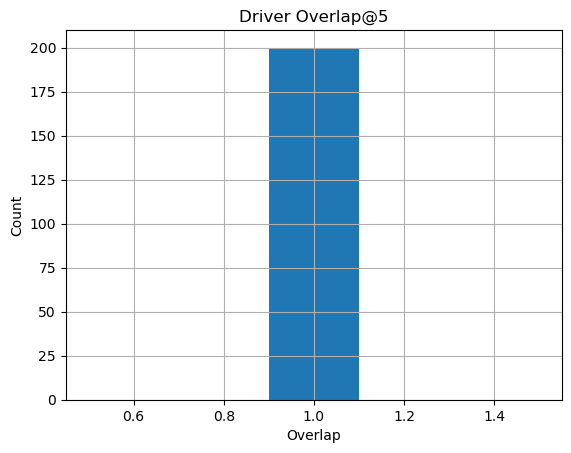

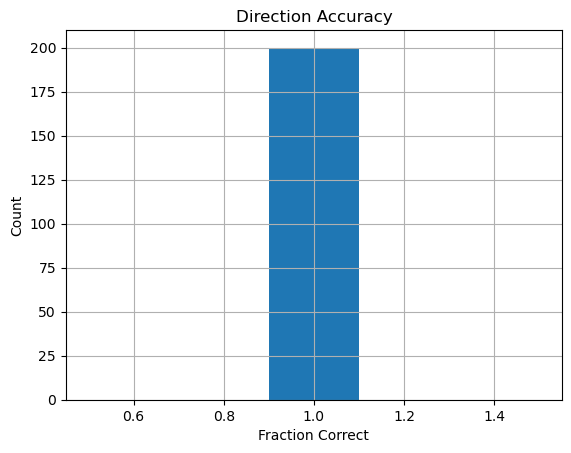

In [10]:
# plot
merged["overlap_at_5"].hist(bins=5)
plt.title("Driver Overlap@5")
plt.xlabel("Overlap")
plt.ylabel("Count")
plt.show()

merged["direction_accuracy"].hist(bins=5)
plt.title("Direction Accuracy")
plt.xlabel("Fraction Correct")
plt.ylabel("Count")
plt.show()

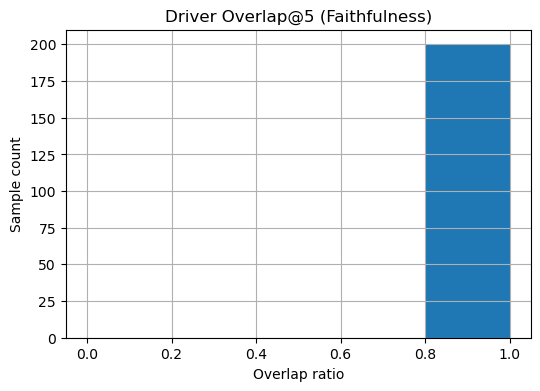

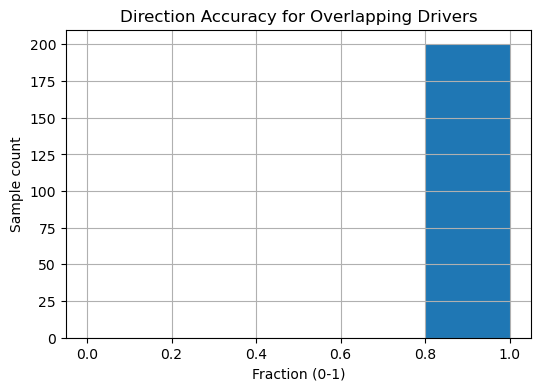

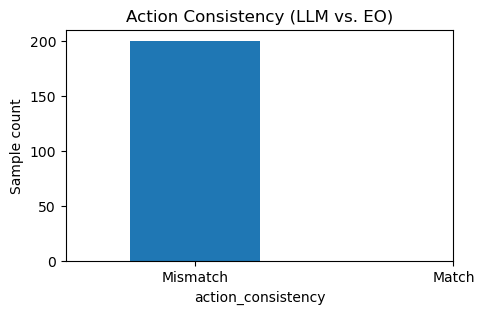

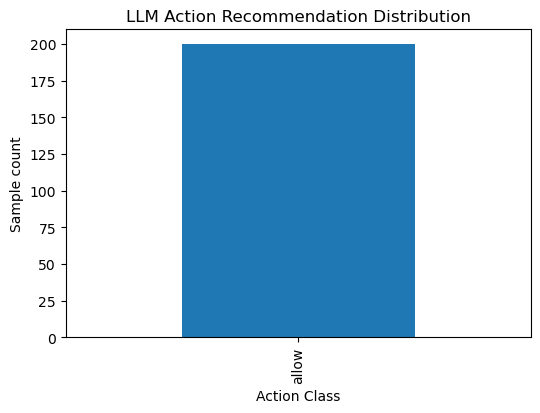

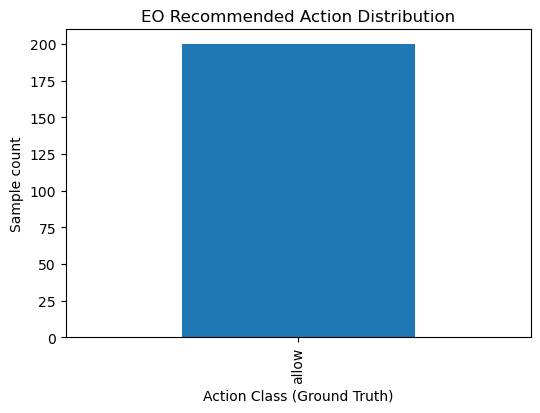

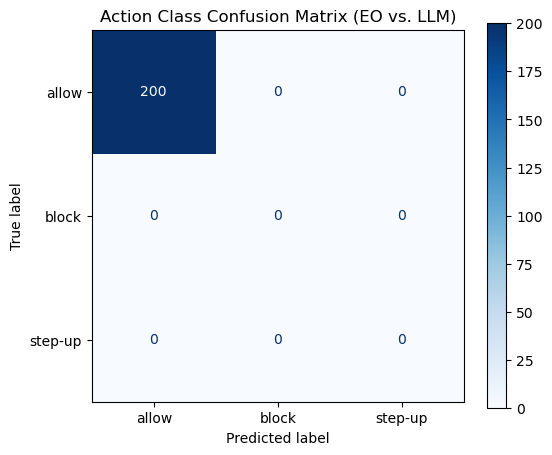

In [16]:
# more plots
import matplotlib.pyplot as plt
import seaborn as sns

# Overlap@5 histogram
plt.figure(figsize=(6,4))
merged["overlap_at_5"].hist(bins=[0,0.2,0.4,0.6,0.8,1.0])
plt.title("Driver Overlap@5 (Faithfulness)")
plt.xlabel("Overlap ratio")
plt.ylabel("Sample count")
plt.show()

# Direction accuracy histogram
plt.figure(figsize=(6,4))
merged["direction_accuracy"].hist(bins=[0,0.2,0.4,0.6,0.8,1.0])
plt.title("Direction Accuracy for Overlapping Drivers")
plt.xlabel("Fraction (0-1)")
plt.ylabel("Sample count")
plt.show()

# Action consistency bar plot
plt.figure(figsize=(5,3))
merged["action_consistency"].value_counts().sort_index().plot(kind='bar')
plt.xticks([0,1], ['Mismatch', 'Match'], rotation=0)
plt.title("Action Consistency (LLM vs. EO)")
plt.ylabel("Sample count")
plt.show()

# Distribution of action_recommendation given by LLM
plt.figure(figsize=(6,4))
merged["narrative"].apply(lambda n: n.get("action_recommendation")).value_counts().plot(kind='bar')
plt.title("LLM Action Recommendation Distribution")
plt.xlabel("Action Class")
plt.ylabel("Sample count")
plt.show()

# Distribution of EO ground truth action
plt.figure(figsize=(6,4))
merged["recommended_action_class"].value_counts().plot(kind='bar')
plt.title("EO Recommended Action Distribution")
plt.xlabel("Action Class (Ground Truth)")
plt.ylabel("Sample count")
plt.show()

# Confusion matrix: EO action vs. LLM action
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

eo_actions = merged["recommended_action_class"]
llm_actions = merged["narrative"].apply(lambda n: n.get("action_recommendation"))
# Explicit list of all possible/expected actions in your use-case:
all_labels = ['allow', 'block', 'step-up']  # add others as needed
cm = confusion_matrix(eo_actions, llm_actions, labels=all_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
plt.title("Action Class Confusion Matrix (EO vs. LLM)")
plt.show()


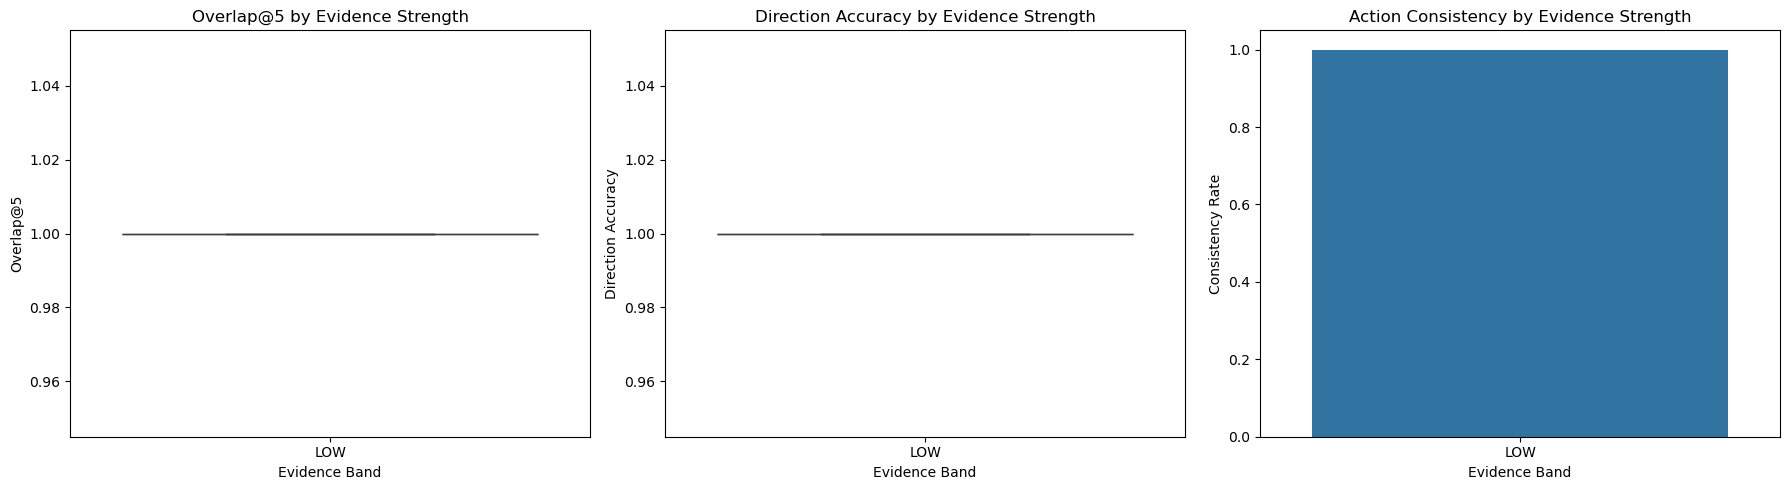

In [18]:
# Plots by evidence_strength
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Overlap@5
sns.boxplot(x="evidence_strength", y="overlap_at_5", data=merged, ax=axes[0])
axes[0].set_title("Overlap@5 by Evidence Strength")
axes[0].set_xlabel("Evidence Band")
axes[0].set_ylabel("Overlap@5")

# Direction Accuracy
sns.boxplot(x="evidence_strength", y="direction_accuracy", data=merged, ax=axes[1])
axes[1].set_title("Direction Accuracy by Evidence Strength")
axes[1].set_xlabel("Evidence Band")
axes[1].set_ylabel("Direction Accuracy")

# Action Consistency
sns.barplot(
    x="evidence_strength",
    y="action_consistency",
    data=merged,
    estimator=lambda x: sum(x)/len(x),  # mean for bool
    ax=axes[2],
)
axes[2].set_title("Action Consistency by Evidence Strength")
axes[2].set_xlabel("Evidence Band")
axes[2].set_ylabel("Consistency Rate")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

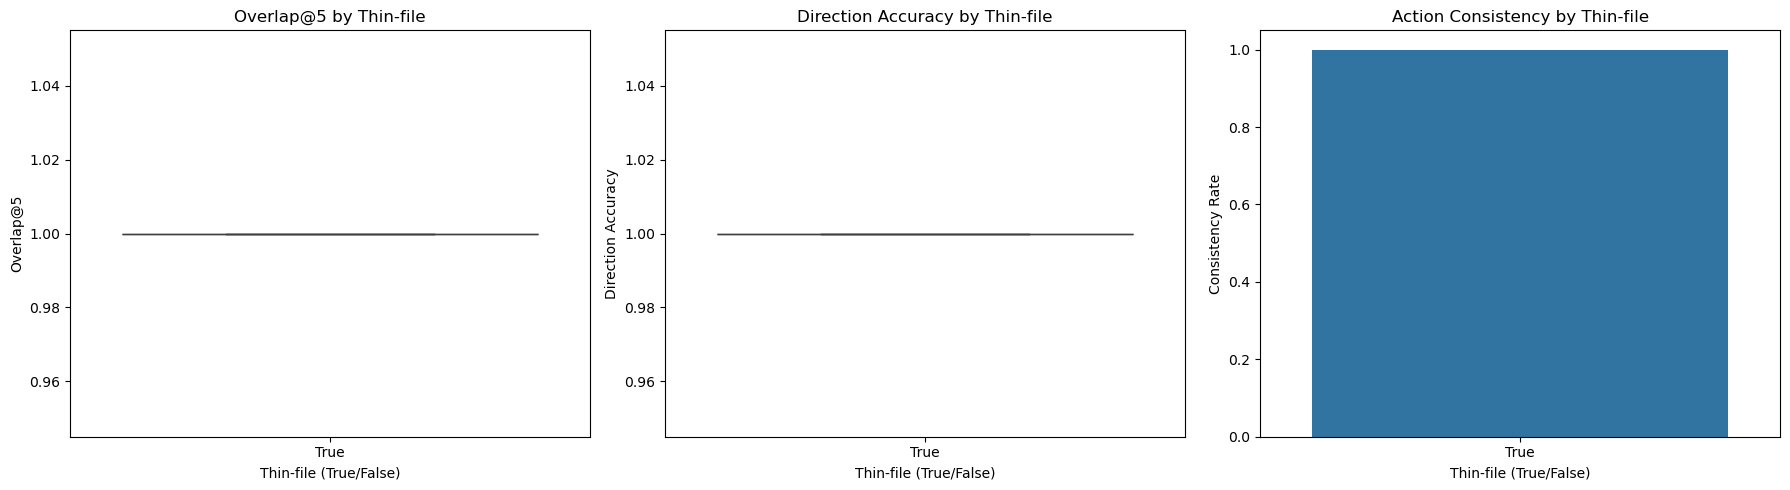

In [19]:
# Plots by thin_file_flag (grid)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Overlap@5
sns.boxplot(x="thin_file_flag", y="overlap_at_5", data=merged, ax=axes[0])
axes[0].set_title("Overlap@5 by Thin-file")
axes[0].set_xlabel("Thin-file (True/False)")
axes[0].set_ylabel("Overlap@5")

# Direction Accuracy
sns.boxplot(x="thin_file_flag", y="direction_accuracy", data=merged, ax=axes[1])
axes[1].set_title("Direction Accuracy by Thin-file")
axes[1].set_xlabel("Thin-file (True/False)")
axes[1].set_ylabel("Direction Accuracy")

# Action Consistency
sns.barplot(
    x="thin_file_flag",
    y="action_consistency",
    data=merged,
    estimator=lambda x: sum(x)/len(x),
    ax=axes[2],
)
axes[2].set_title("Action Consistency by Thin-file")
axes[2].set_xlabel("Thin-file (True/False)")
axes[2].set_ylabel("Consistency Rate")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()